In [2]:
!nvidia-smi

Thu Aug 21 11:38:23 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.08                 Driver Version: 581.08         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   55C    P0             30W /  130W |       0MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import locale
print(locale.getpreferredencoding())

utf-8


In [ ]:
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding

In [3]:
!pip install ultralytics

  Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (19 kB)
  Using cached PyYAML-6.0.2-cp312-cp312-win_amd64.whl.metadata (2.1 kB)
  Using cached scipy-1.16.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached py_cpuinfo-9.0.0-py3-none-any.whl.metadata (794 bytes)
  Using cached pandas-2.3.1-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached charset_normalizer-3.4.3-cp312-cp312-win_amd64.whl.metadata (37 kB)
  Using cached idna-3.10-py3-none-any.whl.metadata (10 kB)
  Using cached urllib3-2.5.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached certifi-2025.8.3-py3-none-any.whl.metadata (2.4 kB)
  Using cached filelock-3.19.1-py3-none-any.whl.metadata (2.1 kB)
  Using cached typing_extensions-4.14


[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
Root_dir = "/content/drive/MyDrive/YOLO_SPOC"


In [4]:
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\naman\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
# model = YOLO("yolo11n.yaml")  # build a new model from YAML
model = YOLO(r"D:\SWARAJ_POC\Yolo_code\best.pt")  # load a pretrained model (recommended for training)
# model = YOLO("yolo11n.yaml").load("yolo11n.pt")  # build from YAML and transfer weights
# model = YOLO("/content/drive/MyDrive/YOLO_SPOC/resultsv5/detect/train5/weights/best.pt")

In [ ]:
data_path="/content/drive/MyDrive/YOLO_SPOC/drawing.v7i.yolov11"

In [ ]:
# results = model.train(data=os.path.join(data_path, "data.yaml"), epochs = 150, batch=4, imgsz = 640 , patience=20 ,optimizer='Adam', lr0=0.01 , plots=True) # train the model

In [ ]:
results = model.train(
    data=os.path.join(data_path, "data.yaml"),
    epochs=300,            # Higher epochs for small dataset (will stop early via patience)
    batch=2,               # Smaller batch for better small-object learning and due to limited data
    imgsz=640,             # Keep 640 (good balance for speed & detail)
    patience=50,           # Give the model more time before stopping early
    optimizer='AdamW',     # AdamW usually generalizes better than Adam for vision tasks
    lr0=0.001,             # Lower learning rate to avoid overshooting (small dataset)
    lrf=0.01,              # Lower final LR fraction for stable convergence
    weight_decay=0.0005,   # Helps avoid overfitting
    warmup_epochs=3,       # Small warmup for stability
    mosaic=0.7,            # Keep some mosaic augmentation to combine multiple drawings
    mixup=0.1,             # Light mixup for variety without distortion
    plots=True
)


In [ ]:
import shutil
import os

source_directory = '/content/runs'#as its is
destination_directory = '/content/drive/MyDrive/YOLO_SPOC/resultsv7'

# Check if the source directory exists
if os.path.exists(source_directory):
    # Create the destination directory if it doesn't exist
    os.makedirs(destination_directory, exist_ok=True)

    # Copy the directory
    shutil.copytree(source_directory, destination_directory, dirs_exist_ok=True)
    print(f"Directory copied from {source_directory} to {destination_directory}")
else:
    print(f"Source directory {source_directory} does not exist.")

Directory copied from /content/runs to /content/drive/MyDrive/YOLO_SPOC/resultsv7


In [ ]:
# import os

# # List the contents of the main directory
# # print(os.listdir('/content/drive/MyDrive/Facial_Dx/NoseTrill'))

# # List the contents of the images directory
# print(os.listdir('/content/drive/MyDrive/Facial_Dx/NoseTrill/image'))


In [ ]:
# Run validation again to get metrics
metrics = model.val()
# Print key metrics
print(f"Precision: {metrics.box.mp:.4f}")  # Mean Precision
print(f"Recall: {metrics.box.mr:.4f}")  # Mean Recall

# Check to prevent division by zero when calculating F1 Score
if metrics.box.mp + metrics.box.mr == 0:
    f1_score = 0.0
else:
    f1_score = 2 * metrics.box.mp * metrics.box.mr / (metrics.box.mp + metrics.box.mr)  # F1 Score calculation

print(f"F1 Score: {f1_score:.4f}")
print(f"mAP@50: {metrics.box.map50:.4f}")  # Mean Average Precision at IoU=0.50
print(f"mAP@50-95: {metrics.box.map:.4f}")  # Mean Average Precision from IoU=0.50 to IoU=0.95

Ultralytics 8.3.177 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,583,712 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 21.7±14.0 MB/s, size: 47.8 KB)


val: Scanning /content/drive/MyDrive/YOLO_SPOC/drawing.v7i.yolov11/valid/labels.cache... 9 images, 0 backgrounds, 0 corrupt: 100%|██████████| 9/9 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:00<00:00,  8.50it/s]


                   all          9         61      0.671      0.599       0.68      0.466
           Detail view          4          8      0.967      0.625       0.73      0.563
        Isometric view          4          5      0.793        0.8      0.866      0.537
        Sectional view          8         10          1      0.574      0.798      0.566
                 Table          7         20      0.889      0.804      0.917      0.651
               Table 1          1          1          0          0          0          0
              Top view          7          9      0.627      0.889      0.825      0.685
                  text          4          8      0.421        0.5      0.627      0.263
Speed: 8.2ms preprocess, 25.6ms inference, 0.0ms loss, 10.9ms postprocess per image
Results saved to runs/detect/train332
Precision: 0.6709
Recall: 0.5988
F1 Score: 0.6328
mAP@50: 0.6803
mAP@50-95: 0.4664


In [ ]:
# import shutil
# import os

# source_directory = '/content/runs'
# destination_directory = '/content/drive/MyDrive/Facial_Dx/NoseTrill/runs'

# # Check if the source directory exists
# if os.path.exists(source_directory):
#     # Create the destination directory if it doesn't exist
#     os.makedirs(destination_directory, exist_ok=True)

#     # Copy the directory
#     shutil.copytree(source_directory, destination_directory, dirs_exist_ok=True)
#     print(f"Directory copied from {source_directory} to {destination_directory}")
# else:
#     print(f"Source directory {source_directory} does not exist.")

In [ ]:
!yolo task=detect mode=predict model='/content/drive/MyDrive/YOLO_SPOC/resultsv5/detect/train/weights/best.pt' source='/content/drive/MyDrive/YOLO_SPOC/drawing.v5i.yolov11/test/images/Screenshot-2025-08-11-131207_png.rf.00b0d182c4a69d5f6c6644e161489329.jpg' conf=0.11 imgsz=640 save=True save_txt=True show_labels=True show_conf=True show_boxes=True


Ultralytics 8.3.176 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,585,077 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/drive/MyDrive/YOLO_SPOC/drawing.v5i.yolov11/test/images/Screenshot-2025-08-11-131207_png.rf.00b0d182c4a69d5f6c6644e161489329.jpg: 640x640 (no detections), 12.6ms
Speed: 3.6ms preprocess, 12.6ms inference, 27.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict4
0 label saved to runs/detect/predict4/labels
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [ ]:
# Predict with the model
# model = YOLO("/content/drive/MyDrive/YOLO_SPOC/resultsv7/detect/train33/weights/best.pt")
results = model("/content/test11.png" , conf = 0.5)  # predict on an image

# Access the results
for result in results:
    xywh = result.boxes.xywh  # center-x, center-y, width, height
    xywhn = result.boxes.xywhn  # normalized
    xyxy = result.boxes.xyxy  # top-left-x, top-left-y, bottom-right-x, bottom-right-y
    xyxyn = result.boxes.xyxyn  # normalized
    names = [result.names[cls.item()] for cls in result.boxes.cls.int()]  # class name of each box
    confs = result.boxes.conf  # confidence score of each box


image 1/1 /content/test11.png: 544x640 3 Tables, 1 Top view, 1 text, 319.8ms
Speed: 6.3ms preprocess, 319.8ms inference, 2.1ms postprocess per image at shape (1, 3, 544, 640)



image 1/1 D:\SWARAJ_POC\Yolo_code\test1.png: 448x640 2 Isometric views, 1 Sectional view, 1 Table, 2 Top views, 1 text, 36.4ms
Speed: 1.7ms preprocess, 36.4ms inference, 0.9ms postprocess per image at shape (1, 3, 448, 640)


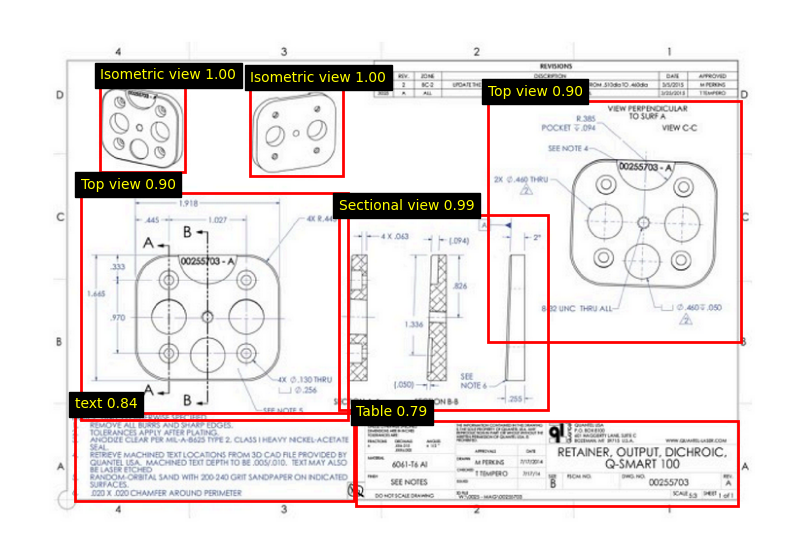

In [7]:
import matplotlib.pyplot as plt
import cv2

# Load image
image_path = r"D:\SWARAJ_POC\Yolo_code\test1.png"
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Run YOLO inference
results = model(image_path,conf= 0.75)

# Plot image
plt.figure(figsize=(10, 8))
plt.imshow(img)
ax = plt.gca()

# Loop through each detection
for result in results:
    xyxy = result.boxes.xyxy.cpu().numpy()  # Bounding boxes (x1, y1, x2, y2)
    confs = result.boxes.conf.cpu().numpy()  # Confidence scores
    names = [result.names[int(cls)] for cls in result.boxes.cls.cpu().numpy()]  # Class names

    for (x1, y1, x2, y2), conf, name in zip(xyxy, confs, names):
        # Draw rectangle
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                             fill=False, color="red", linewidth=2)
        ax.add_patch(rect)

        # Label with class name & confidence
        ax.text(x1, y1 - 5, f"{name} {conf:.2f}",
                color="yellow", fontsize=10, backgroundcolor="black")

plt.axis("off")
plt.show()

In [ ]:
# import shutil
# import os

# source_directory = '/content/runs/detect'
# destination_directory = '/content/drive/MyDrive/Facial_Dx/NoseTrill/runsSanjana/segment/predict/predict1'

# # Check if the source directory exists
# if os.path.exists(source_directory):
#     # Create the destination directory if it doesn't exist
#     os.makedirs(destination_directory, exist_ok=True)

#     # Copy the directory
#     shutil.copytree(source_directory, destination_directory, dirs_exist_ok=True)
#     print(f"Directory copied from {source_directory} to {destination_directory}")
# else:
#     print(f"Source directory {source_directory} does not exist.")

In [ ]:
import shutil
import os

# Define root directory
Root_dir = "/content/drive/MyDrive/YOLO_SPOC"

# Define source and destination paths dynamically
source_directory = os.path.join(Root_dir, "results/detect/predict")
destination_directory = "/content"

# Check if the source directory exists
if os.path.exists(source_directory):
    # Create the destination directory if it doesn't exist
    os.makedirs(destination_directory, exist_ok=True)

    # Copy the directory
    shutil.copytree(source_directory, destination_directory, dirs_exist_ok=True)
    print(f"Directory copied from {source_directory} to {destination_directory}")
else:
    print(f"Source directory {source_directory} does not exist.")


Source directory /content/drive/MyDrive/YOLO_SPOC/results/detect/predict does not exist.


In [ ]:
!pip install supervision

In [ ]:
!pip install inference

/usr/local/lib/python3.11/dist-packages/inference/models/utils.py:356: ModelDependencyMissing: Your `inference` configuration does not support Qwen2.5-VL model. Use pip install 'inference[transformers]' to install missing requirements.To suppress this warning, set QWEN_2_5_ENABLED to False.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/inference/models/utils.py:370: ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[sam]' to install missing requirements.To suppress this warning, set CORE_MODEL_SAM_ENABLED to False.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/inference/models/utils.py:382: ModelDependencyMissing: Your `inference` configuration does not support SAM2 model. Use pip install 'inference[sam]' to install missing requirements.To suppress this warning, set CORE_MODEL_SAM2_ENABLED to False.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/inference/models/utils.py:395: ModelDependencyMissi

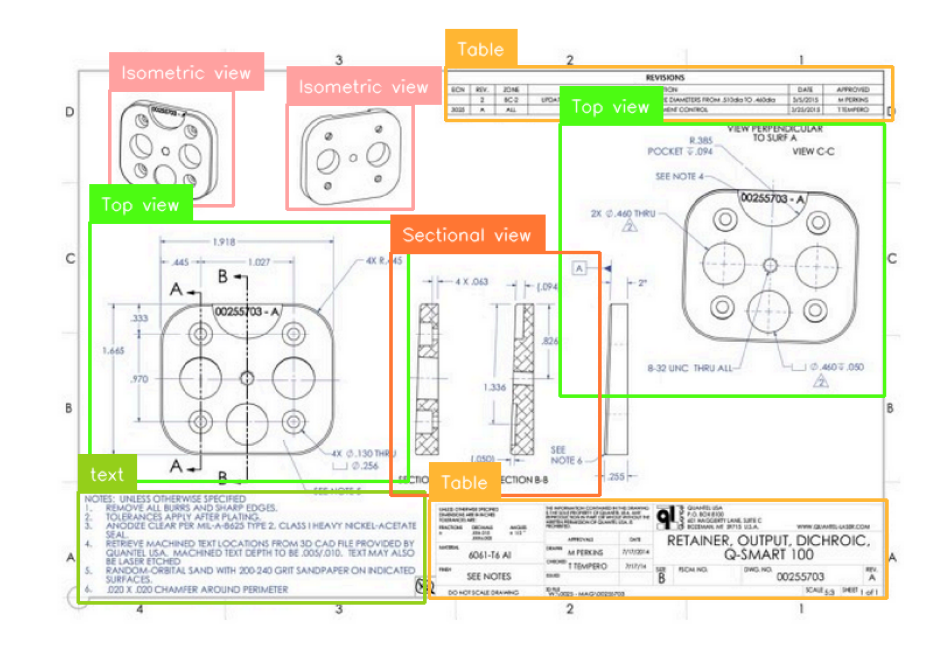

In [ ]:
from inference import get_model
import supervision as sv
import cv2

# define the image url to use for inference
image_file = "/content/test1.png"
image = cv2.imread(image_file)

# load a pre-trained yolov8n model
model = get_model(model_id="drawing-gpc4l/5",api_key="MBZA1dWoOlFLPpi6H3wJ")

# run inference on our chosen image, image can be a url, a numpy array, a PIL image, etc.
results = model.infer(image)[0]

# load the results into the supervision Detections api
detections = sv.Detections.from_inference(results)

# create supervision annotators
bounding_box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

# annotate the image with our inference results
annotated_image = bounding_box_annotator.annotate(
    scene=image, detections=detections)
annotated_image = label_annotator.annotate(
    scene=annotated_image, detections=detections)

# display the image
sv.plot_image(annotated_image)

#Image Extraction

In [ ]:
!pip install pdf2image

In [ ]:
!sudo apt-get install poppler-utils


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.9 [186 kB]
Fetched 186 kB in 1s (313 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package poppler-utils.
(Reading database ... 126284 

In [ ]:
from pdf2image import convert_from_path
import os

# Input PDF file
pdf_path = "/content/page51.pdf"

# Output folder for images
output_dir = "/content/output"
os.makedirs(output_dir, exist_ok=True)

# Convert PDF to images at high DPI for clarity
images = convert_from_path(pdf_path, dpi=600, fmt='png')  # 600 DPI preserves small text

# Save each page as a PNG
for i, img in enumerate(images):
    img_path = os.path.join(output_dir, f"page_{i+1}.png")
    img.save(img_path, "PNG")
    print(f"Saved: {img_path}")

print("✅ Conversion complete! High-quality images are ready.")


Saved: /content/output/page_1.png
✅ Conversion complete! High-quality images are ready.
